## ***DATASET DISTILLATION***

In [ ]:
# Google Colab Setup
!pip install torch torchvision

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 33.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 56.8 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

In [ ]:
# Configurar dispositivo
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Hiperparámetros
NUM_PROTOTYPES = 50  # Número de imágenes destiladas
EPOCHS_TEACHER = 100  # Épocas de entrenamiento del teacher
EPOCHS_STUDENT = 5000  # Épocas de entrenamiento del student
T = 5  # Temperatura para la distillation loss
LR_STUDENT = 0.0005  # Learning rate del student
DISTILLATION_STEPS = 2000  # Número de pasos en dataset distillation

Using device: cuda


In [ ]:
# Cargar dataset MNIST
def load_mnist():
    transform = transforms.Compose([transforms.ToTensor()])
    trainset = torchvision.datasets.MNIST(root='/content/data', train=True, download=True, transform=transform)
    testset = torchvision.datasets.MNIST(root='/content/data', train=False, download=True, transform=transform)
    trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
    testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)
    return trainset, trainloader, testset, testloader

trainset, trainloader, testset, testloader = load_mnist()


Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:00<00:00, 18.0MB/s]


Extracting /content/data/MNIST/raw/train-images-idx3-ubyte.gz to /content/data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 490kB/s]


Extracting /content/data/MNIST/raw/train-labels-idx1-ubyte.gz to /content/data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1.65M/1.65M [00:00<00:00, 4.56MB/s]


Extracting /content/data/MNIST/raw/t10k-images-idx3-ubyte.gz to /content/data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<00:00, 7.62MB/s]

Extracting /content/data/MNIST/raw/t10k-labels-idx1-ubyte.gz to /content/data/MNIST/raw



In [ ]:
# Definir la red neuronal
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(F.max_pool2d(self.conv1(x), 2))
        x = F.relu(F.max_pool2d(self.conv2(x), 2))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

# Entrenar modelo Teacher
def train_teacher():
    teacher = SimpleCNN().to(device)
    optimizer = optim.Adam(teacher.parameters(), lr=0.0001)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(EPOCHS_TEACHER):
        teacher.train()
        total_loss = 0
        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = teacher(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Teacher Epoch {epoch+1}, Loss: {total_loss/len(trainloader):.4f}")

    return teacher

In [ ]:

# Generar dataset distillado
def dataset_distillation(teacher):
    distilled_images = torch.randn((NUM_PROTOTYPES, 1, 28, 28), requires_grad=True, device=device)
    distilled_labels = torch.randint(0, 10, (NUM_PROTOTYPES,), device=device)
    optimizer = optim.Adam([distilled_images], lr=0.1)

    for step in range(DISTILLATION_STEPS):
        optimizer.zero_grad()
        teacher_logits = teacher(distilled_images)
        loss = F.cross_entropy(teacher_logits, distilled_labels)
        loss.backward()
        optimizer.step()

    return distilled_images.detach()

In [ ]:
# Evaluar modelo
def evaluate_model(model, testloader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return correct / total

In [ ]:
# Entrenar modelo Student
def train_student(teacher, distilled_images, distilled_labels):
    student = SimpleCNN().to(device)
    optimizer = optim.Adam(student.parameters(), lr=LR_STUDENT)
    criterion = nn.KLDivLoss(reduction='batchmean')

    distilled_loader = torch.utils.data.DataLoader(list(zip(distilled_images, distilled_labels)), batch_size=10, shuffle=True)

    for epoch in range(EPOCHS_STUDENT):
        student.train()
        total_loss = 0
        for images, labels in distilled_loader:
            images, labels = images.to(device), labels.to(device)
            with torch.no_grad():
                teacher_logits = teacher(images)
            student_logits = student(images)
            loss = criterion(F.log_softmax(student_logits / T, dim=1), F.softmax(teacher_logits / T, dim=1))
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        if (epoch + 1) % 500 == 0:
            print(f"Student Epoch {epoch+1}, Loss: {total_loss/len(distilled_loader):.4f}")

    return student

In [ ]:
# Función para visualizar los datos
def plot_comparison(trainset, distilled_images):
    fig, axes = plt.subplots(2, 10, figsize=(15, 3))

    # Muestras del dataset original
    for i in range(10):
        axes[0, i].imshow(trainset.data[i].cpu().numpy(), cmap="gray")
        axes[0, i].axis("off")
        axes[0, i].set_title(f"Orig {trainset.targets[i].item()}")

    # Muestras del dataset destilado
    for i in range(10):
        axes[1, i].imshow(distilled_images[i].cpu().squeeze(), cmap="gray")
        axes[1, i].axis("off")
        axes[1, i].set_title(f"Distilled {i}")

    plt.suptitle("Comparación: Original vs Distillado")
    plt.show()


In [ ]:
if __name__ == "__main__":
    teacher_model = train_teacher()
    accuracy_full = evaluate_model(teacher_model, testloader)
    print(f"Precisión del modelo Teacher: {accuracy_full:.4f}")

    synthetic_data = dataset_distillation(teacher_model)
    plot_comparison(trainset, synthetic_data)

    distilled_labels = torch.randint(0, 10, (NUM_PROTOTYPES,), device=device)
    student_model = train_student(teacher_model, synthetic_data, distilled_labels)
    accuracy_distilled = evaluate_model(student_model, testloader)
    print(f"Precisión del modelo Student: {accuracy_distilled:.4f}")

    data = {"Modelo": ["Teacher", "Student"], "Precisión": [accuracy_full, accuracy_distilled]}
    df = pd.DataFrame(data)
    print(df)



Teacher Epoch 1, Loss: 0.7210
Teacher Epoch 2, Loss: 0.2385
Teacher Epoch 3, Loss: 0.1611
Teacher Epoch 4, Loss: 0.1191
Teacher Epoch 5, Loss: 0.0948
Teacher Epoch 6, Loss: 0.0793
Teacher Epoch 7, Loss: 0.0688
Teacher Epoch 8, Loss: 0.0609
Teacher Epoch 9, Loss: 0.0548
Teacher Epoch 10, Loss: 0.0501
Teacher Epoch 11, Loss: 0.0457
Teacher Epoch 12, Loss: 0.0421
Teacher Epoch 13, Loss: 0.0388


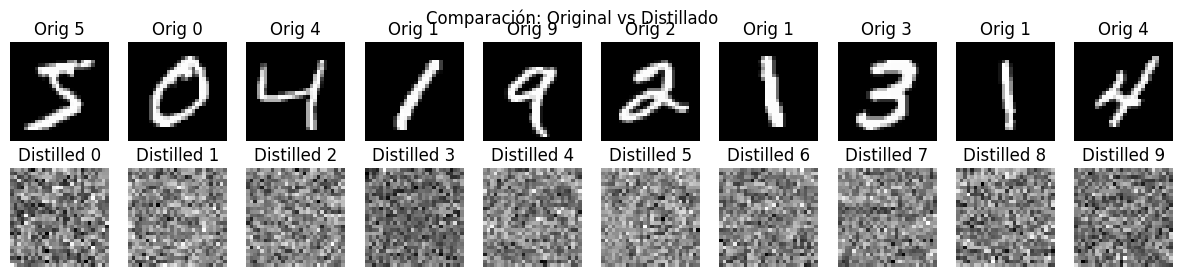

In [ ]:
    # Visualizar comparación
    plot_comparison(trainset, synthetic_data)